In [19]:
import numpy as np
import pandas as pd

# Data Extraction

In [20]:
DIR_PATH = "./data/"
FILE_NAME = "Mall_Customers.csv"

df = pd.read_csv(DIR_PATH + FILE_NAME)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Data Validation

In [21]:
### --------- Data understanding ----------------------------- ###

num_cols = df.select_dtypes(include= ['number'])
cat_cols = df.select_dtypes(include=['object', 'category'])

print("Numerical columns in data set:", num_cols.shape[1])
print("Categorical columns in data set:", cat_cols.shape[1])


Numerical columns in data set: 4
Categorical columns in data set: 1


In [22]:
# Missing and duplicated values

print("----------- Missing Values---------------")
print(df.isnull().sum())

print("----------- Duplicated Values -----------")
print(df.duplicated().sum())


----------- Missing Values---------------
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
----------- Duplicated Values -----------
0


Missing values per column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


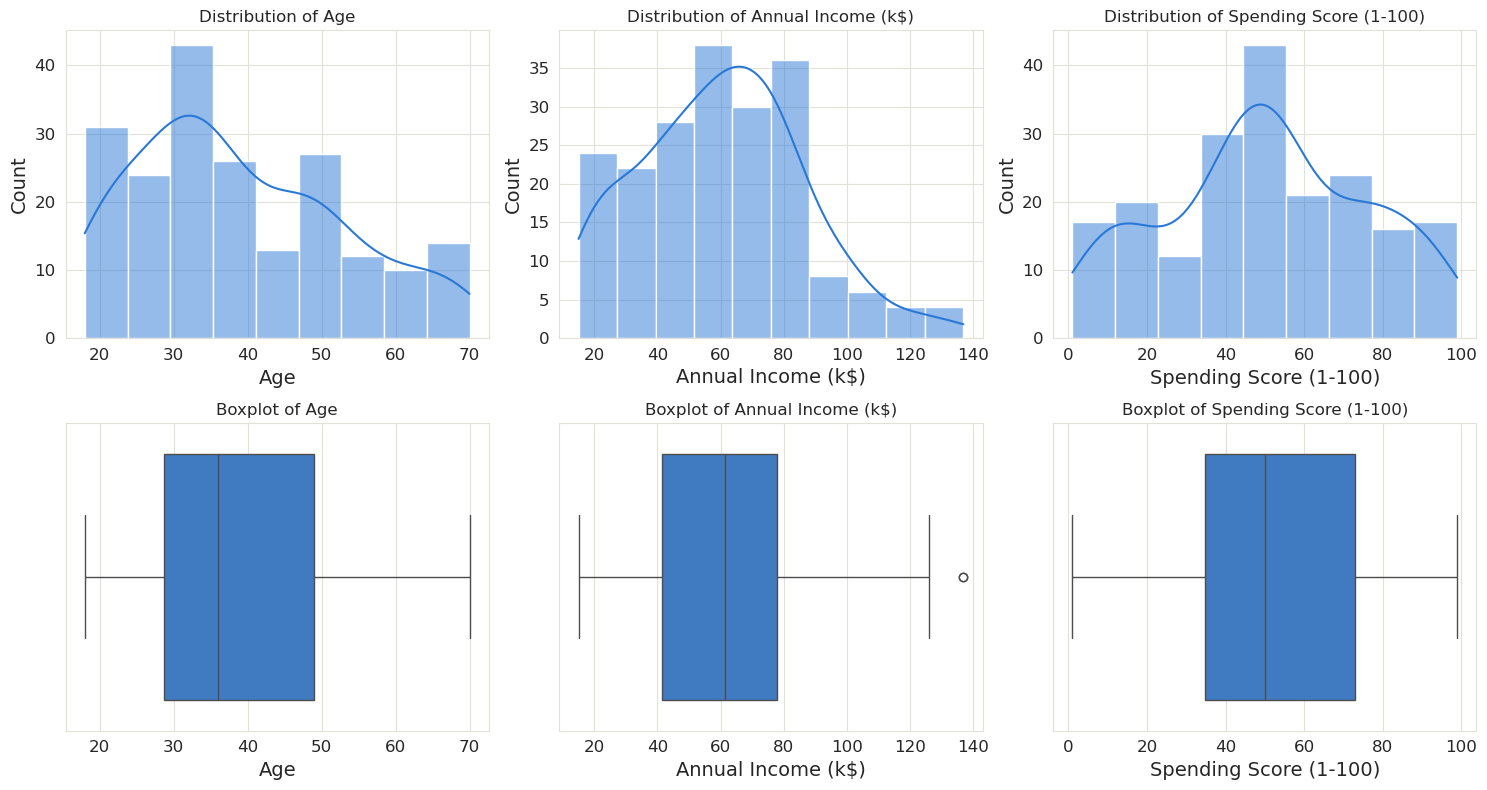

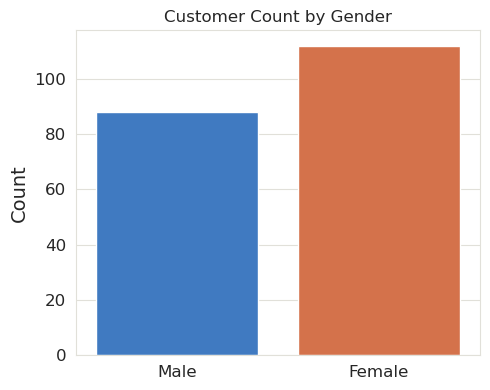

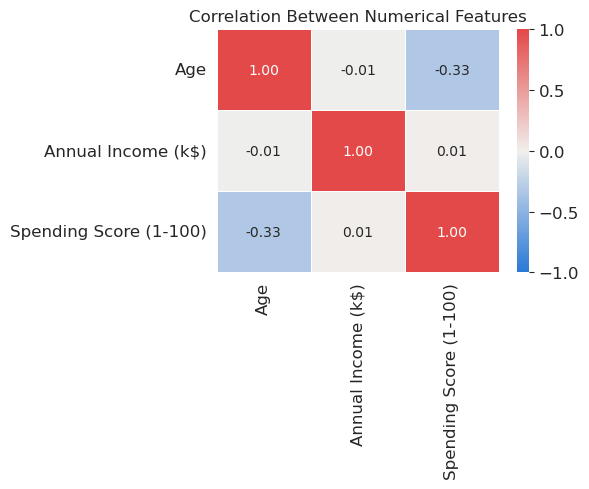

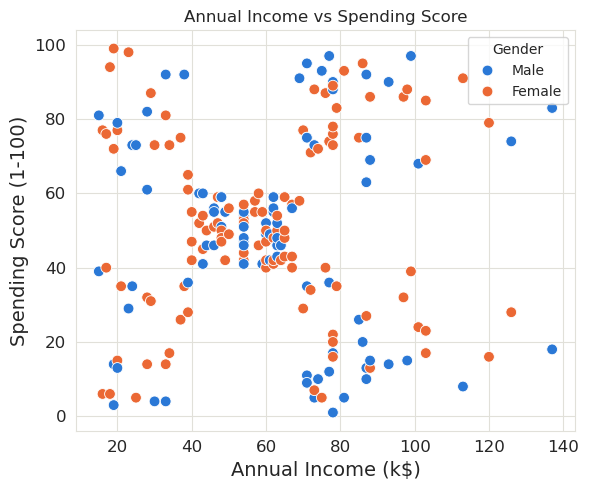

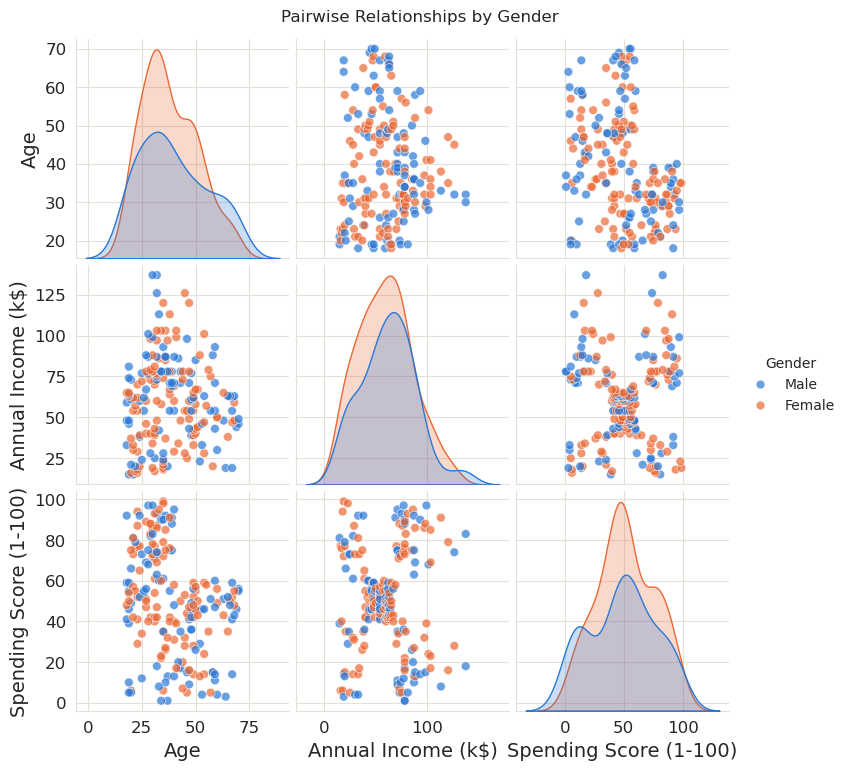

In [23]:
### ------- visualizations ------------------------ ###

import seaborn as sns
import math

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.axes._base as mpl_base
import matplotlib.cbook as mpl_cbook
from matplotlib.colors import LinearSegmentedColormap
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
_orig_check_1d = mpl_cbook._check_1d

def _check_1d_pandas_safe(x):
    if isinstance(x, (pd.Series, pd.Index)):
        x = x.to_numpy()
    return _orig_check_1d(x)

mpl_base._check_1d = _check_1d_pandas_safe

# ---- palette (fixed categorical order, one sequential hue, one diverging pair) ----
COLOR_BLUE   = "#2a78d6"   # categorical slot 1 / sequential hue
COLOR_ORANGE = "#eb6834"   # categorical slot 2
COLOR_RED    = "#e34948"   # diverging pole
COLOR_GRAY   = "#f0efec"   # diverging midpoint
GRID_COLOR   = "#e1e0d9"

gender_order = ["Male", "Female"]
gender_palette = {"Male": COLOR_BLUE, "Female": COLOR_ORANGE}
diverging_cmap = LinearSegmentedColormap.from_list("blue_red", [COLOR_BLUE, COLOR_GRAY, COLOR_RED])

sns.set_style("whitegrid", {"grid.color": GRID_COLOR, "axes.edgecolor": GRID_COLOR})

numeric_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

# ---- 1. Missing values check ----
print("Missing values per column:\n", df.isnull().sum())

# ---- 2. Distributions + boxplots for the numeric features ----
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, color=COLOR_BLUE, ax=axes[0, i])
    axes[0, i].set_title(f"Distribution of {col}")
    axes[0, i].set_xlabel(col)

    sns.boxplot(x=df[col], color=COLOR_BLUE, ax=axes[1, i])
    axes[1, i].set_title(f"Boxplot of {col}")
    axes[1, i].set_xlabel(col)

plt.tight_layout()
plt.show()

# ---- 3. Gender distribution ----
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="Gender", data=df, order=gender_order,
                    hue="Gender", palette=gender_palette, legend=False)
ax.set_title("Customer Count by Gender")
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# ---- 4. Correlation heatmap ----
plt.figure(figsize=(6, 5))
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap=diverging_cmap,
            vmin=-1, vmax=1, center=0, linewidths=0.5, linecolor="white")
plt.title("Correlation Between Numerical Features")
plt.tight_layout()
plt.show()

# ---- 5. Annual Income vs Spending Score (key view for segmentation) ----
plt.figure(figsize=(6, 5))
ax = sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                      hue="Gender", hue_order=gender_order, palette=gender_palette, s=60)
ax.set_title("Annual Income vs Spending Score")
plt.tight_layout()
plt.show()

# ---- 6. Pairwise relationships across all numeric features ----
pair_grid = sns.pairplot(df, vars=numeric_features, hue="Gender", hue_order=gender_order,
                          palette=gender_palette, diag_kind="kde",
                          plot_kws={"alpha": 0.7, "s": 40})
pair_grid.fig.suptitle("Pairwise Relationships by Gender", y=1.02)
plt.show()

In [24]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Feature Engine

In [25]:
# Lets include useful new features

# Spending-to-Income ratio: spending propensity relative to means, not just raw spend
df["Spending_Income_Ratio"] = df["Spending Score (1-100)"] / df["Annual Income (k$)"]

# Age group bins: for cluster profiling, not for clustering distance itself
age_bins = [18, 25, 35, 45, 55, 65, 100]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
df["Age_Group"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels, include_lowest=True)

# Income tier bins: same rationale as Age_Group
income_bins = [0, 40, 70, 100, df["Annual Income (k$)"].max() + 1]
income_labels = ["Low", "Mid", "High", "Very High"]
df["Income_Tier"] = pd.cut(df["Annual Income (k$)"], bins=income_bins, labels=income_labels, include_lowest=True)

df[["Age", "Age_Group", "Annual Income (k$)", "Income_Tier",
    "Spending Score (1-100)", "Spending_Income_Ratio"]].head()

,Age,Age_Group,Annual Income (k$),Income_Tier,Spending Score (1-100),Spending_Income_Ratio
0,19,18-25,15,Low,39,2.600000
1,21,18-25,15,Low,81,5.400000
2,20,18-25,16,Low,6,0.375000
3,23,18-25,16,Low,77,4.812500
4,31,26-35,17,Low,40,2.352941


# Data Preprocessing 

In [26]:

from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encode Gender for reference/profiling only -- not used as a clustering feature,
# a binary dummy mixed with continuous features would distort Euclidean distance
le = LabelEncoder()
df["Gender_Code"] = le.fit_transform(df["Gender"])

cluster_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_features])

X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features, index=df.index)
X_scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


# Model Training

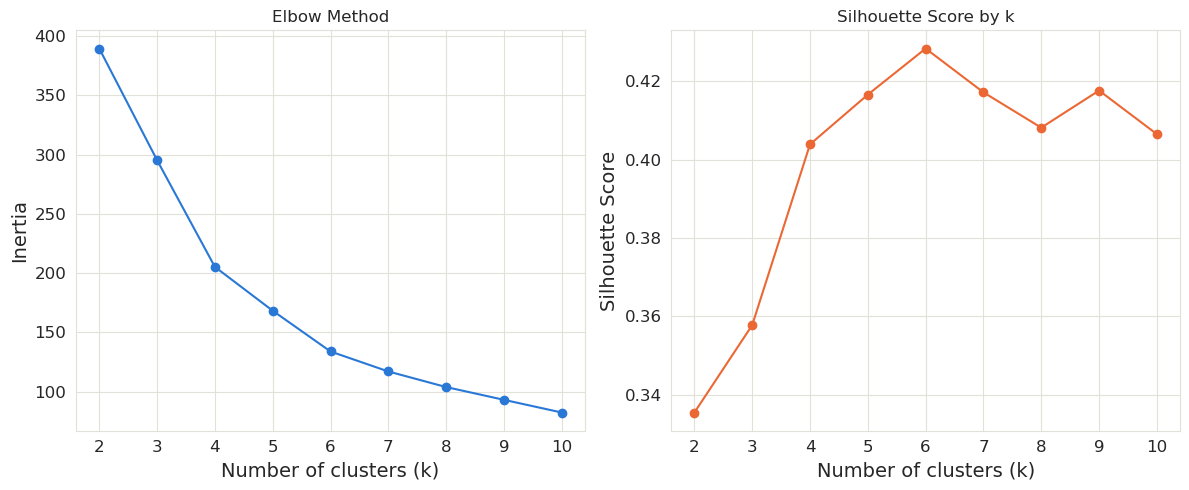

Best k by silhouette score: 6


Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64

In [27]:
### ------- KMeans model training ------------------------ ###

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---- Select k via elbow (inertia) and silhouette score ----
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled_df)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_df, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(list(k_range), inertias, marker="o", color=COLOR_BLUE)
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color=COLOR_ORANGE)
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"Best k by silhouette score: {best_k}")

# ---- Fit the final model on the chosen k ----
kmeans = KMeans(n_clusters=best_k, init="k-means++", n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled_df)

df["Cluster"].value_counts().sort_index()

# Model Analysis

,Age,Annual Income (k$),Spending Score (1-100),Spending_Income_Ratio,Count,% Female
Cluster,,,,,,
0,56.3,54.3,49.1,0.9,45,57.8
1,26.8,57.1,48.1,0.9,39,64.1
2,41.9,88.9,17.0,0.2,33,42.4
3,32.7,86.5,82.1,1.0,39,53.8
4,25.0,25.3,77.6,3.3,23,56.5
5,45.5,26.3,19.4,0.8,21,61.9


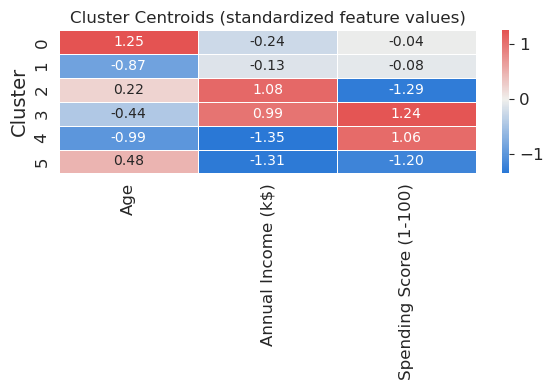

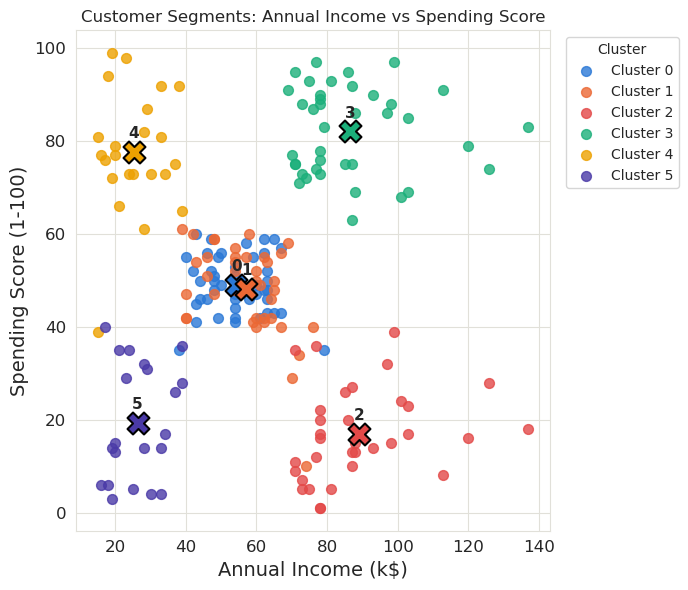

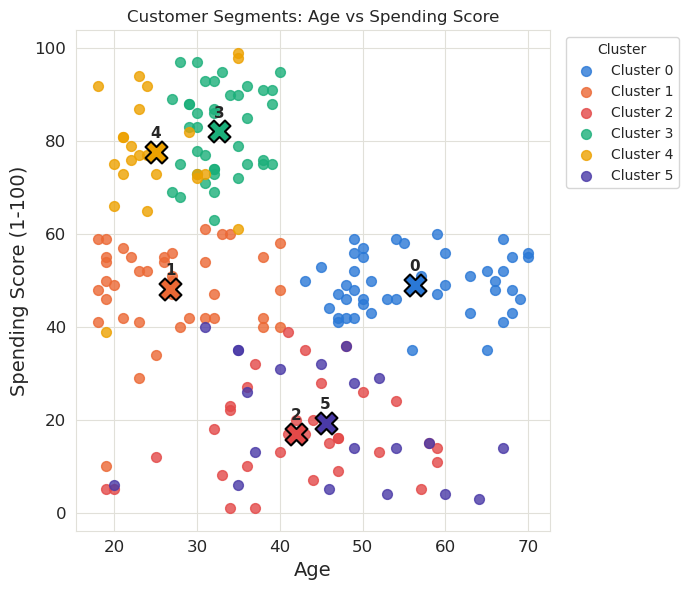

In [ ]:
### ------- cluster profiling ------------------------ ###

from IPython.display import display

cluster_palette = [COLOR_BLUE, COLOR_ORANGE, COLOR_RED, "#1baf7a", "#eda100", "#4a3aa7"]
cluster_order = sorted(df["Cluster"].unique())
cluster_colors = {c: cluster_palette[i] for i, c in enumerate(cluster_order)}

# ---- 1. Cluster profile summary: size, mean feature values, gender mix ----
cluster_profile = df.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)",
                                          "Spending_Income_Ratio"]].mean().round(1)
cluster_profile["Count"] = df.groupby("Cluster").size()
cluster_profile["% Female"] = df.groupby("Cluster")["Gender"].apply(lambda s: (s == "Female").mean() * 100).round(1)
display(cluster_profile)

# ---- 2. Cluster centroids (standardized feature space) ----
centroid_df = pd.DataFrame(kmeans.cluster_centers_, columns=cluster_features)
centroid_df.index.name = "Cluster"

plt.figure(figsize=(6, 4))
sns.heatmap(centroid_df, annot=True, fmt=".2f", cmap=diverging_cmap, center=0,
            linewidths=0.5, linecolor="white")
plt.title("Cluster Centroids (standardized feature values)")
plt.tight_layout()
plt.show()

# Centroids back in original (unscaled) units, for plotting against the raw features
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

# ---- 3. Income vs Spending Score, colored by cluster ----
plt.figure(figsize=(7, 6))
for c in cluster_order:
    # plotting data
    subset = df[df["Cluster"] == c]
    plt.scatter(subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
                s=50, alpha=0.8, color=cluster_colors[c], label=f"Cluster {c}")

for c, (age_c, income_c, spend_c) in zip(cluster_order, centroids_original):
    # plotting centroids
    plt.scatter(income_c, spend_c, s=250, marker="X", color=cluster_colors[c],
                edgecolor="black", linewidth=1.5, zorder=5)
    plt.annotate(str(c), (income_c, spend_c), textcoords="offset points",
                 xytext=(0, 10), ha="center", fontsize=11, fontweight="bold")

plt.title("Customer Segments: Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---- 4. Age vs Spending Score, colored by cluster ----
plt.figure(figsize=(7, 6))
for c in cluster_order:
    subset = df[df["Cluster"] == c]
    plt.scatter(subset["Age"], subset["Spending Score (1-100)"],
                s=50, alpha=0.8, color=cluster_colors[c], label=f"Cluster {c}")

for c, (age_c, income_c, spend_c) in zip(cluster_order, centroids_original):
    plt.scatter(age_c, spend_c, s=250, marker="X", color=cluster_colors[c],
                edgecolor="black", linewidth=1.5, zorder=5)
    plt.annotate(str(c), (age_c, spend_c), textcoords="offset points",
                 xytext=(0, 10), ha="center", fontsize=11, fontweight="bold")

plt.title("Customer Segments: Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Model Validation

In [29]:
### ------- model validation ------------------------ ###

from sklearn.metrics import silhouette_samples, adjusted_rand_score

# ---- 1. Cluster stability: does the chosen partition hold up across independent
# random restarts, or was best_k/the final labeling a fluke of one random_state? ----
n_runs = 10
ari_scores = []

for seed in range(n_runs):
    km_run = KMeans(n_clusters=best_k, init="k-means++", n_init=10, random_state=seed)
    labels_run = km_run.fit_predict(X_scaled_df)
    ari_scores.append(adjusted_rand_score(df["Cluster"], labels_run))

print(f"Adjusted Rand Index vs. the fitted model, across {n_runs} independent random seeds:")
print(f"  mean = {np.mean(ari_scores):.3f}, min = {np.min(ari_scores):.3f}, max = {np.max(ari_scores):.3f}")
print("  (1.0 = identical partition, 0.0 = random agreement -- values near 1 mean the")
print("   clustering is a stable structure in the data, not an artifact of one seed)")

# ---- 2. Per-cluster silhouette: is every cluster well-separated, or is one of them
# propping up the average while actually overlapping its neighbors? ----
df["Silhouette"] = silhouette_samples(X_scaled_df, df["Cluster"])

silhouette_by_cluster = df.groupby("Cluster")["Silhouette"].agg(["mean", "min", "max"]).round(3)
display(silhouette_by_cluster)

negative_pct = (df["Silhouette"] < 0).mean() * 100
print(f"Share of points with negative silhouette (likely on a cluster boundary/misassigned): {negative_pct:.1f}%")

# ---- 3. Are the scaling parameters actually doing their job? Compare each feature's
# original spread against how much its centroids move in standardized space -- if
# scaling worked, no single feature should dominate just because of its raw units ----
scale_check = pd.DataFrame({
    "Feature": cluster_features,
    "Original Mean": scaler.mean_,
    "Original Std": scaler.scale_,
    "Centroid Range (standardized)": (centroid_df.max() - centroid_df.min()).values,
})
display(scale_check)

Adjusted Rand Index vs. the fitted model, across 10 independent random seeds:
  mean = 0.992, min = 0.988, max = 1.000
  (1.0 = identical partition, 0.0 = random agreement -- values near 1 mean the
   clustering is a stable structure in the data, not an artifact of one seed)


,mean,min,max
Cluster,,,
0,0.491,0.148,0.644
1,0.387,0.008,0.613
2,0.331,-0.013,0.544
3,0.505,0.283,0.640
4,0.508,0.056,0.659
5,0.294,-0.065,0.513


Share of points with negative silhouette (likely on a cluster boundary/misassigned): 1.5%


,Feature,Original Mean,Original Std,Centroid Range (standardized)
0,Age,38.85,13.934041,2.248690
1,Annual Income (k$),60.56,26.198977,2.430573
2,Spending Score (1-100),50.20,25.758882,2.529555


# Model deployment

In [30]:
### ------- model deployment: batch scoring via serialized artifacts ------------------------ ###

import joblib
from pathlib import Path

# ---- 1. Persist the fitted preprocessing + model artifacts ----
MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(scaler, MODEL_DIR / "scaler.joblib")
joblib.dump(kmeans, MODEL_DIR / "kmeans.joblib")
joblib.dump(cluster_features, MODEL_DIR / "cluster_features.joblib")

print(f"Artifacts saved to {MODEL_DIR.resolve()}")

# ---- 2. Reusable scoring function for new customer batches ----
def assign_segment(new_df, scaler=scaler, kmeans=kmeans, features=cluster_features):
    """Score a batch of new customers with the persisted scaler + KMeans model."""
    X_new_scaled = pd.DataFrame(scaler.transform(new_df[features]), columns=features, index=new_df.index)
    return kmeans.predict(X_new_scaled)

# Sanity check: re-scoring the training data should reproduce the same labels
assert (assign_segment(df) == df["Cluster"]).all(), "Scoring function does not reproduce training labels"
print("Scoring function verified against training data.")

# ---- 3. Human-readable segment name per cluster, derived from the existing
# -- cluster ids are arbitrary and this stays correct if the data or k changes ----
segment_names = (
    df.groupby("Cluster")
      .agg(Income_Tier=("Income_Tier", lambda s: s.mode()[0]),
           Age_Group=("Age_Group", lambda s: s.mode()[0]))
      .apply(lambda row: f"{row['Income_Tier']} Income / {row['Age_Group']}", axis=1)
)
df["Segment_Name"] = df["Cluster"].map(segment_names)

display(segment_names)

# ---- 4. Export outputs for downstream consumption (e.g. a BI dashboard) ----
EXPORT_DIR = Path("./exports")
EXPORT_DIR.mkdir(exist_ok=True)

customer_export_cols = ["CustomerID", "Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)",
                         "Spending_Income_Ratio", "Age_Group", "Income_Tier", "Cluster", "Segment_Name"]
df[customer_export_cols].to_csv(EXPORT_DIR / "customer_segments.csv", index=False)

segment_summary = df.groupby(["Cluster", "Segment_Name"])[["Age", "Annual Income (k$)",
                                                             "Spending Score (1-100)", "Spending_Income_Ratio"]].mean().round(1)
segment_summary["Count"] = df.groupby(["Cluster", "Segment_Name"]).size()
segment_summary.to_csv(EXPORT_DIR / "segment_summary.csv")

print(f"Exported customer-level and segment-level CSVs to {EXPORT_DIR.resolve()}")

Artifacts saved to /home/cristianm/ClaudeProjects/Client Segmentation/models
Scoring function verified against training data.


Cluster
0     Mid Income / 46-55
1     Mid Income / 18-25
2    High Income / 36-45
3    High Income / 26-35
4     Low Income / 18-25
5     Low Income / 46-55
dtype: object

Exported customer-level and segment-level CSVs to /home/cristianm/ClaudeProjects/Client Segmentation/exports
